# Predective modeling of Early-Stage CKD Prediction System
---

# Dataset Collection and Exploratory Data Analysis (EDA)

In [ ]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ssl 
import requests
from io import StringIO
import urllib3


In [16]:
# Disable SSL warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://raw.githubusercontent.com/patilgirish815/Kidney_Cancer_Prediction_Using_Machine_Learning/main/dataset/kidney_disease.csv"

# Download with SSL verification disabled
response = requests.get(url, verify=False)
response.raise_for_status()

# Read CSV
df = pd.read_csv(
    StringIO(response.text),
    na_values=['?', '\t?']
)

print(df.head())

   id   age    bp     sg   al   su     rbc        pc         pcc          ba  \
0   0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2   2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3   3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4   4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

   ...   pcv      wc   rc  htn   dm  cad  appet   pe  ane classification  
0  ...  44.0  7800.0  5.2  yes  yes   no   good   no   no            ckd  
1  ...  38.0  6000.0  NaN   no   no   no   good   no   no            ckd  
2  ...  31.0  7500.0  NaN   no  yes   no   poor   no  yes            ckd  
3  ...  32.0  6700.0  3.9  yes   no   no   poor  yes  yes            ckd  
4  ...  35.0  7300.0  4.6   no   no   no   good   no   no            ckd  

[5 rows x 26 columns]


In [17]:
df.loc[20:25]  # Display the first few rows of the dataset

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
20,20,61.0,80.0,1.015,2.0,0.0,abnormal,abnormal,notpresent,notpresent,...,24.0,9200.0,3.2,yes,yes,yes,poor,yes,yes,ckd
21,21,60.0,90.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,...,32.0,6200.0,3.6,yes,yes,yes,good,no,no,ckd
22,22,48.0,80.0,1.025,4.0,0.0,normal,abnormal,notpresent,notpresent,...,32.0,6900.0,3.4,yes,no,no,good,no,yes,ckd
23,23,21.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,...,NaN,NaN,NaN,no,no,no,poor,no,yes,ckd
24,24,42.0,100.0,1.015,4.0,0.0,normal,abnormal,notpresent,present,...,39.0,8300.0,4.6,yes,no,no,poor,no,no,ckd
25,25,61.0,60.0,1.025,0.0,0.0,NaN,normal,notpresent,notpresent,...,29.0,8400.0,3.7,yes,yes,no,good,no,yes,ckd


In [18]:
df.columns # before renaming, check the column names

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='str')

In [19]:
# Drop the 'id' column if it exists, as it has no clinical/predictive value
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# 3. Rename columns for better readability
columns_mapping = {
    'bp': 'blood_pressure', 'sg': 'specific_gravity', 'al': 'albumin', 'su': 'sugar',
    'rbc': 'red_blood_cells', 'pc': 'pus_cell', 'pcc': 'pus_cell_clumps', 'ba': 'bacteria',
    'bgr': 'blood_glucose_random', 'bu': 'blood_urea', 'sc': 'serum_creatinine', 
    'sod': 'sodium', 'pot': 'potassium', 'hemo': 'hemoglobin', 'pcv': 'packed_cell_volume',
    'wc': 'white_blood_cell_count', 'rc': 'red_blood_cell_count', 'htn': 'hypertension',
    'dm': 'diabetes_mellitus', 'cad': 'coronary_artery_disease', 'appet': 'appetite',
    'pe': 'pedal_edema', 'ane': 'anemia', 'classification': 'target' # Updated mapping
}
df.rename(columns=columns_mapping, inplace=True)
# print(df.head())

# Clean target variable (removing any invisible tabs/spaces)
df['target'] = df['target'].str.strip()
df['target'] = df['target'].map({'ckd': 1, 'notckd': 0}) 

In [20]:
df.head()  # Display the first few rows of the dataset for verification column renaming and target cleaning

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [21]:
df.columns # after renaming, check the column names

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'pedal_edema', 'anemia', 'target'],
      dtype='str')

In [22]:
# 4. Basic Inspection
print("Dataset Shape:", df.shape)
print("\n--- Data Types & Missing Values ---")
print(df.info())

Dataset Shape: (400, 25)

--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    str    
 6   pus_cell                 335 non-null    str    
 7   pus_cell_clumps          396 non-null    str    
 8   bacteria                 396 non-null    str    
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 

In [23]:
print("Null value counts:\n", df.isnull().sum())


Null value counts:
 age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
hemoglobin                  52
packed_cell_volume          71
white_blood_cell_count     106
red_blood_cell_count       131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
target                       0
dtype: int64


In [24]:
print("Cross-tabulation of target variable:\n", df['target'].value_counts())

Cross-tabulation of target variable:
 target
1    250
0    150
Name: count, dtype: int64


/var/folders/y5/6pv_2jw54jqblm__20x22yjc0000gn/T/ipykernel_97056/948061288.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'])


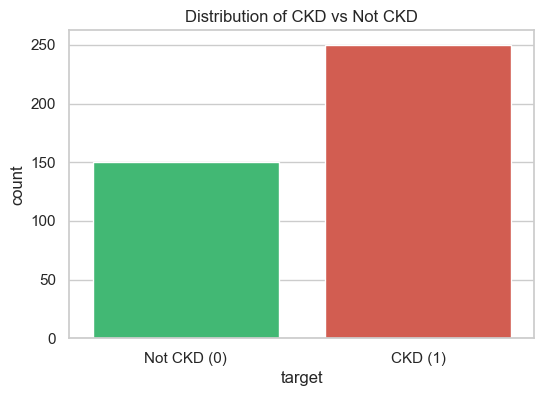

In [25]:
# 5. Visualizing the Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette=['#2ecc71', '#e74c3c'])
plt.title("Distribution of CKD vs Not CKD")
plt.xticks(ticks=[0, 1], labels=['Not CKD (0)', 'CKD (1)'])
plt.show()

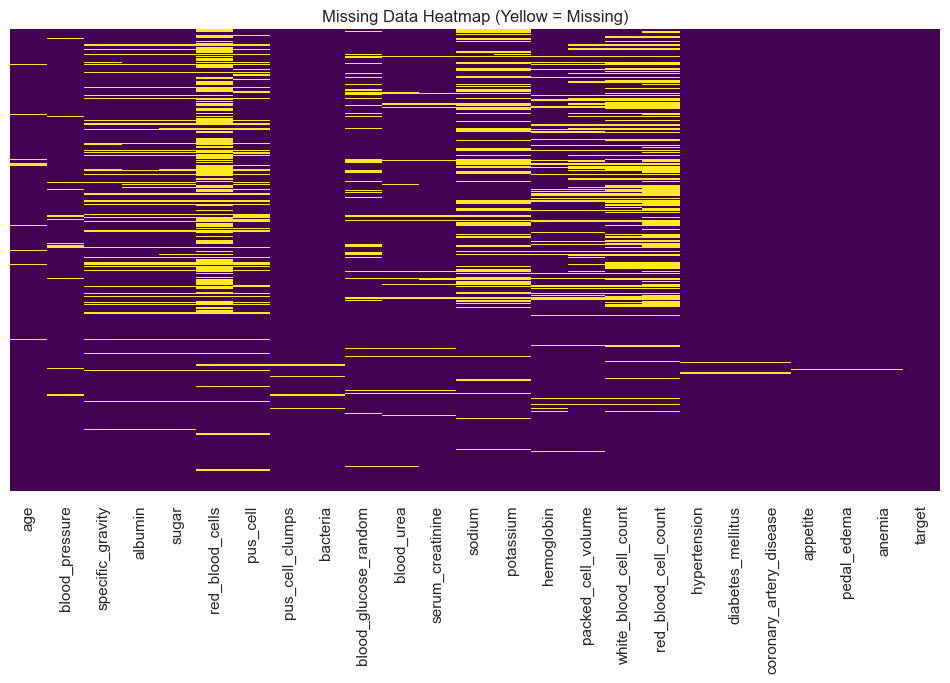

In [26]:
# 6. Visualizing Missing Data Patterns
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data Heatmap (Yellow = Missing)")
plt.show()

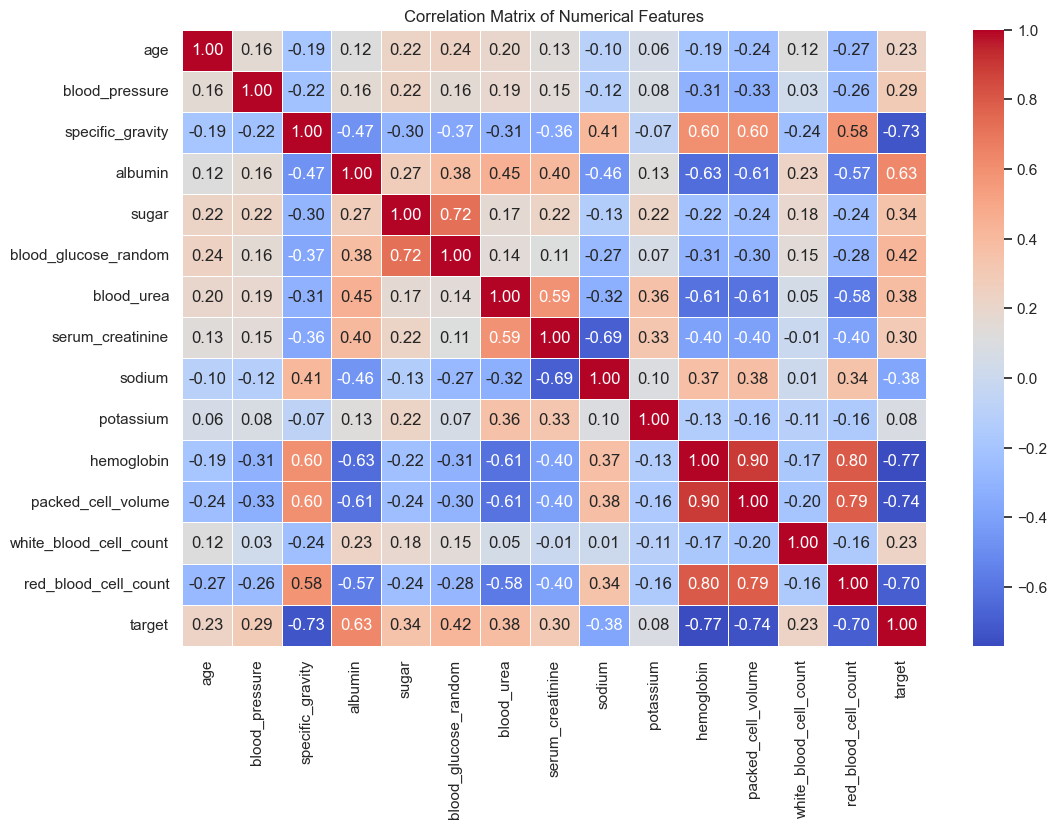

In [27]:
# 7. Correlation matrix for numerical features
plt.figure(figsize=(12, 8))
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Data Cleaning and Preprocessing

In [28]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

print("Starting Data Cleaning...")

# 1. Clean invisible typos (tabs and spaces) in categorical columns
# The dataset has hidden strings like '\tyes', ' yes', or '\tno'
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # Convert to string, strip whitespace and tabs, then replace 'nan' back to actual np.nan
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)

Starting Data Cleaning...


/var/folders/y5/6pv_2jw54jqblm__20x22yjc0000gn/T/ipykernel_97056/3645161387.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [29]:
df.head()  # Display the first few rows of the dataset

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [30]:
# 2. Fix Incorrect Data Types
# These columns are numerical but got parsed as objects due to typos in the raw file
cols_to_numeric = ['packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count']
for col in cols_to_numeric:
    # errors='coerce' forces any unreadable text (like '?') to become NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [31]:
df.age.skew()# Check skewness of numerical features to understand distribution
# skew -0.5 to 

np.float64(-0.6682594691593559)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'blood_pressure'}>,
        <Axes: title={'center': 'specific_gravity'}>,
        <Axes: title={'center': 'albumin'}>,
        <Axes: title={'center': 'sugar'}>],
       [<Axes: title={'center': 'blood_glucose_random'}>,
        <Axes: title={'center': 'blood_urea'}>,
        <Axes: title={'center': 'serum_creatinine'}>,
        <Axes: title={'center': 'sodium'}>,
        <Axes: title={'center': 'potassium'}>],
       [<Axes: title={'center': 'hemoglobin'}>,
        <Axes: title={'center': 'packed_cell_volume'}>,
        <Axes: title={'center': 'white_blood_cell_count'}>,
        <Axes: title={'center': 'red_blood_cell_count'}>,
        <Axes: title={'center': 'target'}>],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

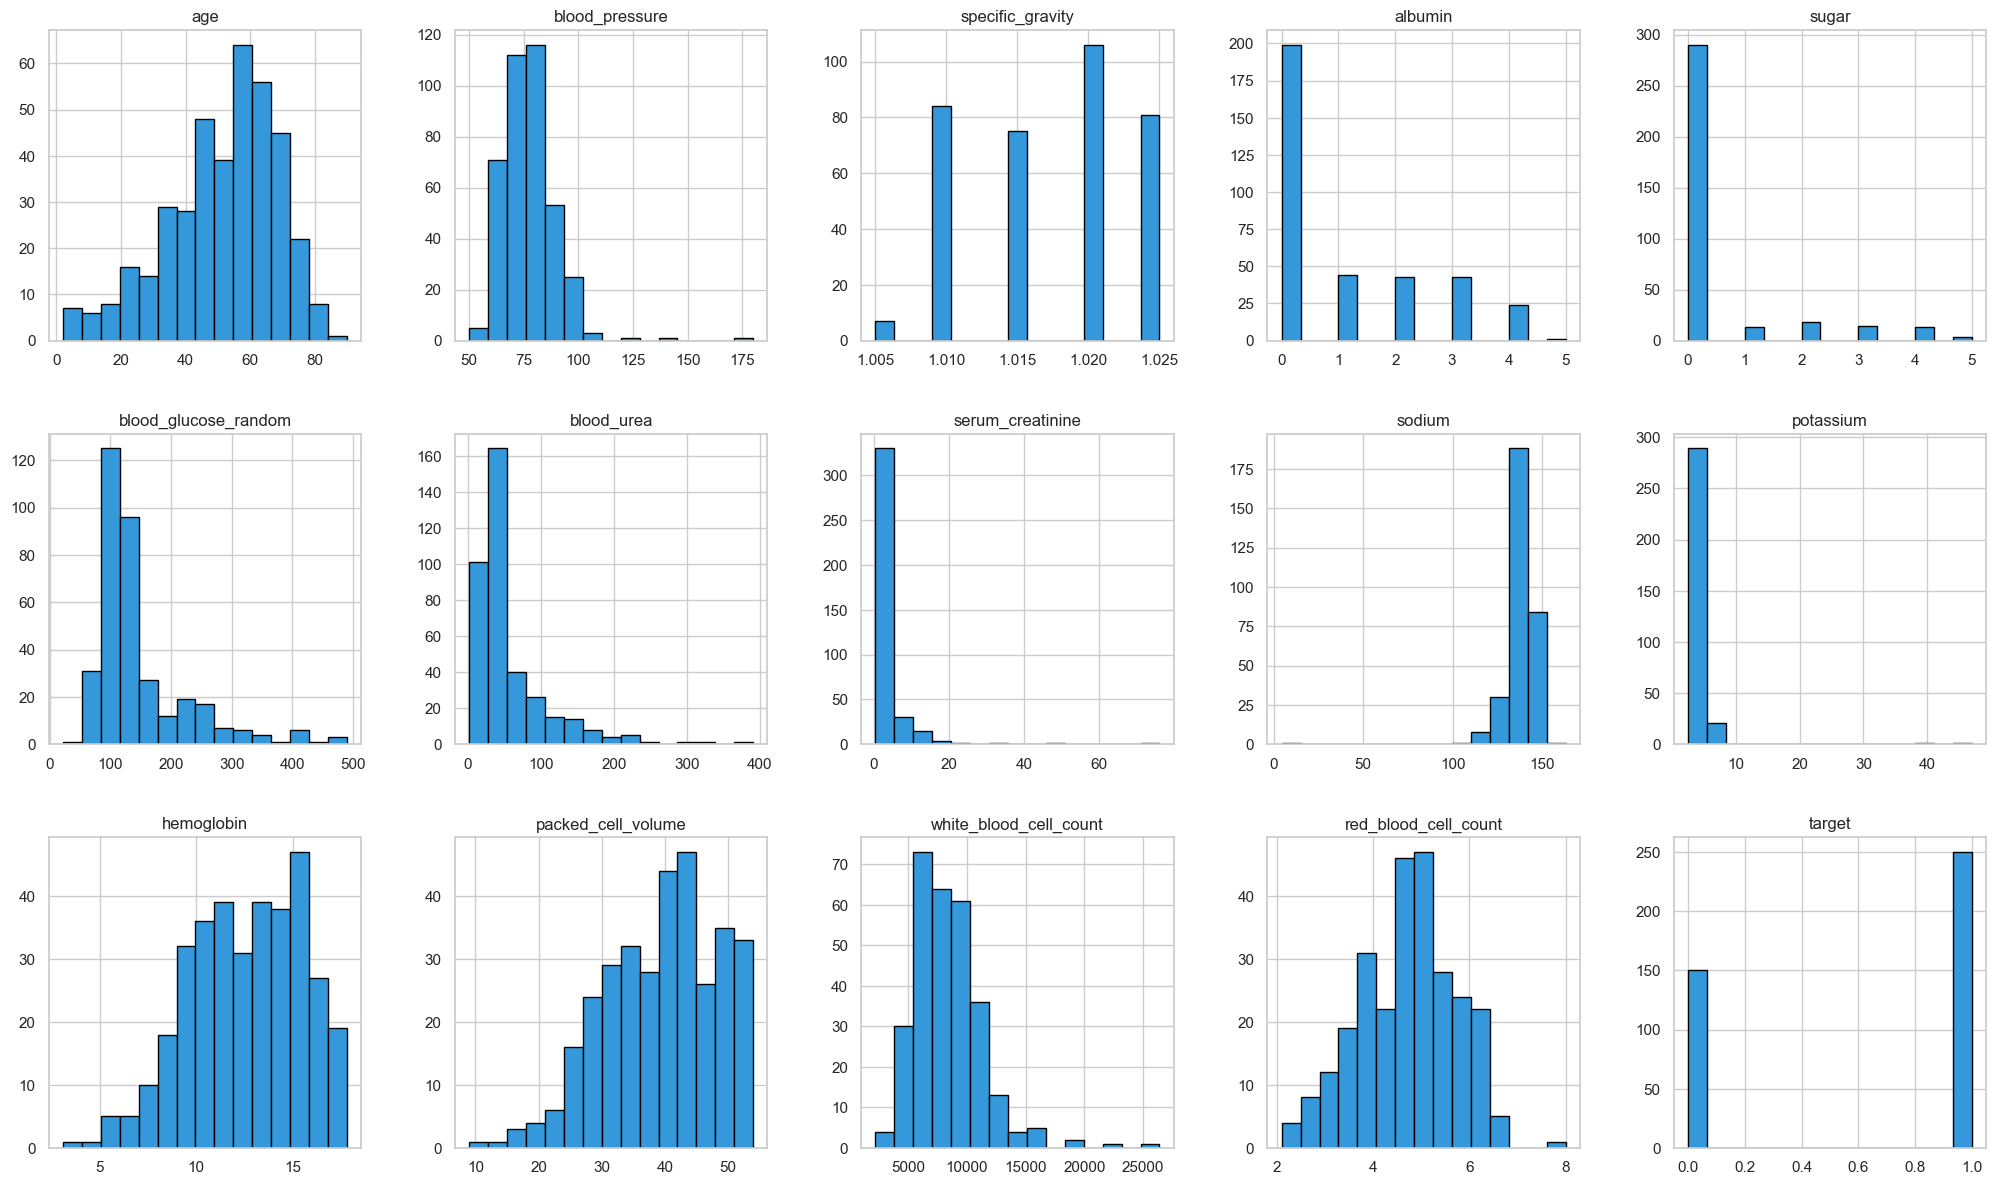

In [32]:
df.hist(bins=15, figsize=(25, 25), layout=(5, 5), color='#3498db', edgecolor='black')

In [33]:
df.head()  # Display the first few rows of the dataset before handling missing values

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,1


In [34]:
# 3. Handle Missing Values (Imputation)
# Update our lists of categorical and numerical columns after the dtype fix
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Do NOT impute the target variable! Drop it from the numerical list temporarily.
if 'target' in numerical_cols:
    numerical_cols = numerical_cols.drop('target')

# A. Categorical Imputation: Fill missing with Mode (most frequent value)
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# B. Numerical Imputation: Use KNN Imputer (Research-level)
print("Applying KNN Imputation for numerical features...")
knn_imputer = KNNImputer(n_neighbors=5)
df[numerical_cols] = knn_imputer.fit_transform(df[numerical_cols])

Applying KNN Imputation for numerical features...


/var/folders/y5/6pv_2jw54jqblm__20x22yjc0000gn/T/ipykernel_97056/2723300367.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [35]:
# 4. Encode Categorical Variables (Label Encoding)
# Machine Learning models need numbers, not text like 'normal' or 'abnormal'
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le # We save the encoder for deployment later!

In [36]:
# 5. Final Sanity Check
print("\n--- Data Types After Cleaning ---")
print(df.info())
print("\n--- Total Missing Values After Cleaning ---")
print(df.isnull().sum()) # Should print 0


--- Data Types After Cleaning ---
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    float64
 1   blood_pressure           400 non-null    float64
 2   specific_gravity         400 non-null    float64
 3   albumin                  400 non-null    float64
 4   sugar                    400 non-null    float64
 5   red_blood_cells          400 non-null    int64  
 6   pus_cell                 400 non-null    int64  
 7   pus_cell_clumps          400 non-null    int64  
 8   bacteria                 400 non-null    int64  
 9   blood_glucose_random     400 non-null    float64
 10  blood_urea               400 non-null    float64
 11  serum_creatinine         400 non-null    float64
 12  sodium                   400 non-null    float64
 13  potassium                400 non-null    float64
 14  he

In [37]:
print("\n--- Total Missing Values After Cleaning ---")
print(df.isnull().sum())


--- Total Missing Values After Cleaning ---
age                        0
blood_pressure             0
specific_gravity           0
albumin                    0
sugar                      0
red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
blood_glucose_random       0
blood_urea                 0
serum_creatinine           0
sodium                     0
potassium                  0
hemoglobin                 0
packed_cell_volume         0
white_blood_cell_count     0
red_blood_cell_count       0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
pedal_edema                0
anemia                     0
target                     0
dtype: int64


In [38]:
df.describe()  # Display summary statistics of the dataset after cleaning

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,target
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,51.31900,76.315000,1.017170,1.055000,0.464500,0.882500,0.810000,0.105000,0.055000,149.280500,...,38.933500,8466.950000,4.695250,0.367500,0.34250,0.085000,0.205000,0.190000,0.150000,0.625000
std,17.08832,13.571708,0.005481,1.287057,1.049998,0.322418,0.392792,0.306937,0.228266,76.522105,...,8.392375,2590.669338,0.898295,0.482728,0.47514,0.279231,0.404207,0.392792,0.357519,0.484729
min,2.00000,50.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,...,9.000000,2200.000000,2.100000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.00000,70.000000,1.013000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,100.150000,...,33.000000,6900.000000,4.100000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.00000,80.000000,1.016000,0.300000,0.000000,1.000000,1.000000,0.000000,0.000000,122.000000,...,40.100000,8380.000000,4.770000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,64.00000,80.000000,1.020000,2.000000,0.000000,1.000000,1.000000,0.000000,0.000000,171.000000,...,45.000000,9600.000000,5.260000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,1.000000
max,90.00000,180.000000,1.025000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,...,54.000000,26400.000000,8.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


# Data Splitting, Scaling, and Feature Selection

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [40]:
print("Starting Splitting, Scaling, and Feature Selection...")

# 1. Separate Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

Starting Splitting, Scaling, and Feature Selection...


In [41]:
# 2. Train-Test Split (Stratified)
# test_size=0.2 means 20% for testing, 80% for training.
# random_state=42 ensures reproducibility (you get the exact same split every time you run it)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training data shape: (320, 24)
Testing data shape: (80, 24)
Training target shape: (320,)
Testing target shape: (80,)


In [42]:
# 3. Feature Scaling (Preventing Data Leakage)
scaler = StandardScaler()

# FIT on the training data ONLY, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# ONLY transform the test data (do NOT fit it)
X_test_scaled = scaler.transform(X_test)

# Convert NumPy arrays back to Pandas DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

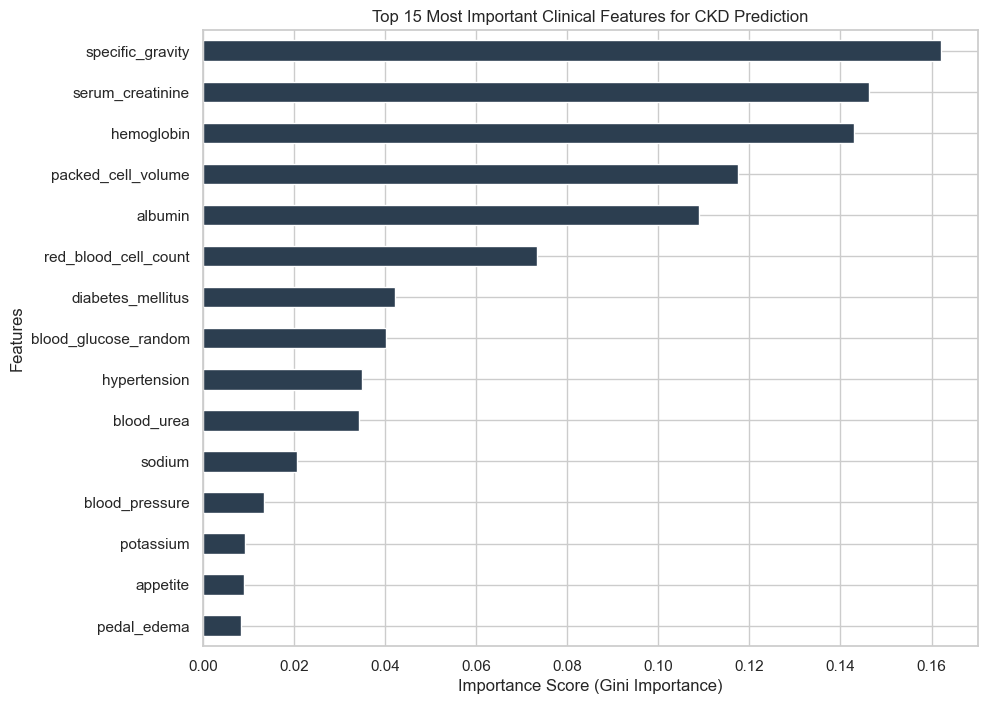

In [62]:
# 4. Feature Selection (Using Random Forest Importance)
# This model is just to calculate feature importance for our research
rf_selector = RandomForestClassifier(random_state=42, n_estimators=100)
rf_selector.fit(X_train_scaled, y_train)

# Create a DataFrame for visualization
feature_importances = pd.Series(rf_selector.feature_importances_, index=X.columns)

# Plotting the Top 15 Most Important Features
plt.figure(figsize=(10, 8))
feature_importances.nlargest(15).plot(kind='barh', color='#2c3e50')
plt.title("Top 15 Most Important Clinical Features for CKD Prediction")
plt.xlabel("Importance Score (Gini Importance)")
plt.ylabel("Features")
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

# Baseline Modeling and Model Comparison

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [45]:
print("Training Baseline Models...\n")

# 1. Initialize our dictionary of models
# random_state=42 ensures the algorithms use the same internal random seed for reproducible research
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# List to store our evaluation metrics
results = []

Training Baseline Models...



In [46]:
# 2. Train and Evaluate each model in a loop
for model_name, model in models.items():
    # Train the model on the training data
    model.fit(X_train_scaled, y_train)
    
    # Predict on the unseen testing data
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Append to our results list
    results.append([model_name, acc, prec, rec, f1])

In [47]:
# 3. Create a Comparison Table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

# Sort the table by Recall (most important for medical), then F1-Score
results_df = results_df.sort_values(by=["Recall", "F1-Score"], ascending=[False, False]).reset_index(drop=True)

print("--- Model Comparison Results ---")
print(results_df.to_string(index=False))

--- Model Comparison Results ---
                 Model  Accuracy  Precision  Recall  F1-Score
         Random Forest    0.9875   1.000000    0.98  0.989899
   Logistic Regression    0.9750   1.000000    0.96  0.979592
Support Vector Machine    0.9750   1.000000    0.96  0.979592
     Gradient Boosting    0.9625   0.979592    0.96  0.969697


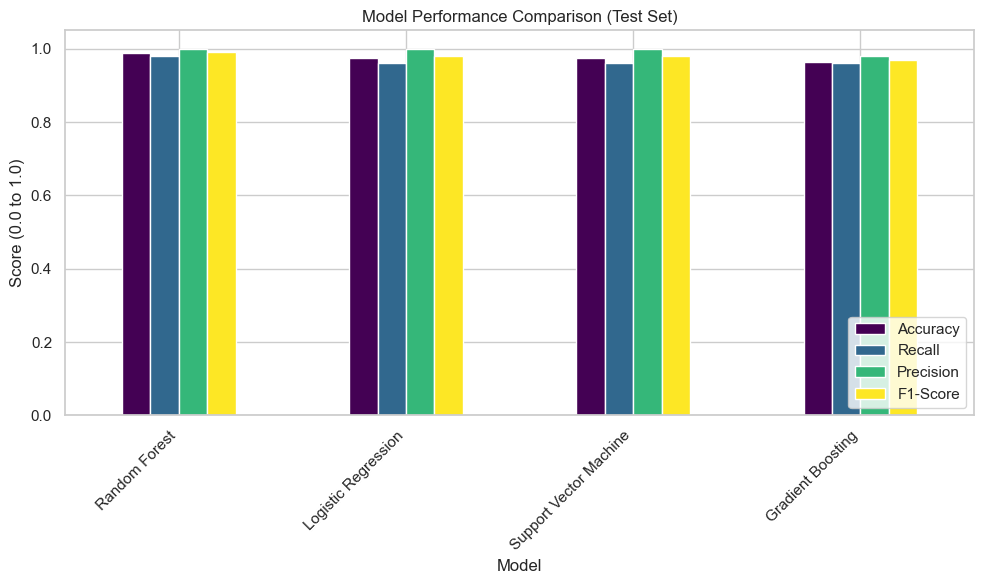

In [48]:
# 4. Visualizing the Comparison
plt.figure(figsize=(10, 6))
# Using pandas built-in plotting for a quick grouped bar chart
results_df.set_index("Model")[["Accuracy","Recall", "Precision", "F1-Score"]].plot(kind='bar', colormap='viridis', ax=plt.gca())
plt.title("Model Performance Comparison (Test Set)")
plt.ylabel("Score (0.0 to 1.0)")
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning (Squeezing out that last 2%)

In [49]:
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning for Random Forest...")

# 1. Define the "Grid" of parameters to test
# This tells the algorithm to try combinations of these numbers
param_grid = {
    'n_estimators': [50, 100, 200],          # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],         # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],         # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],           # Minimum samples required to be at a leaf node
    'class_weight': ['balanced', None]       # Crucial for medical data: tells the model to care equally about both classes
}

Starting Hyperparameter Tuning for Random Forest...


In [50]:
# 2. Initialize the Grid Search
# We explicitly tell it to score based on 'recall' because that is our medical priority
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5,                 # 5-fold cross-validation
    scoring='recall',     # Optimize for Recall!
    n_jobs=-1,            # Use all available CPU cores to speed it up
    verbose=1             # Print progress
)

In [51]:
# 3. Run the Grid Search (This might take 10-30 seconds depending on your machine)
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [52]:
# 4. Extract the Best Model
best_rf_model = grid_search.best_estimator_

print("\n--- Best Hyperparameters Found ---")
print(grid_search.best_params_)


--- Best Hyperparameters Found ---
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [53]:
# 5. Evaluate the Tuned Model on the Unseen Test Data
y_pred_tuned = best_rf_model.predict(X_test_scaled)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("\n--- Tuned Random Forest Results ---")
print(f"Accuracy:  {tuned_acc:.4f} (Baseline: {results_df.loc[0, 'Accuracy']:.4f})")
print(f"Precision: {tuned_prec:.4f} (Baseline: {results_df.loc[0, 'Precision']:.4f})")
print(f"Recall:    {tuned_rec:.4f} (Baseline: {results_df.loc[0, 'Recall']:.4f})")
print(f"F1-Score:  {tuned_f1:.4f} (Baseline: {results_df.loc[0, 'F1-Score']:.4f})")


--- Tuned Random Forest Results ---
Accuracy:  0.9875 (Baseline: 0.9875)
Precision: 1.0000 (Baseline: 1.0000)
Recall:    0.9800 (Baseline: 0.9800)
F1-Score:  0.9899 (Baseline: 0.9899)


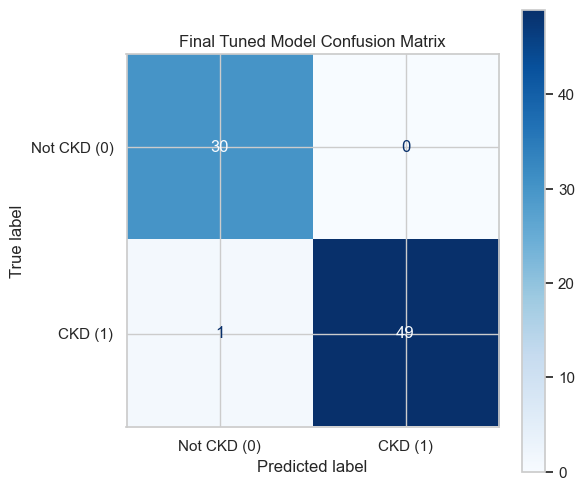

In [54]:
# 6. Plot the Final Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not CKD (0)', 'CKD (1)'])
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Final Tuned Model Confusion Matrix")
plt.show()

# Explainable AI (XAI) with SHAP

In [55]:
import shap

print("Generating SHAP Explainability Plots...")

Generating SHAP Explainability Plots...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [56]:
# 1. Initialize the SHAP TreeExplainer with our best tuned model
# TreeExplainer is highly optimized for Random Forests
explainer = shap.TreeExplainer(best_rf_model)

In [57]:
# 2. Calculate SHAP values for the unseen test data
# This computes the contribution of each feature for every patient in the test set
shap_values = explainer.shap_values(X_test_scaled)

# Note: Random Forest classifiers output SHAP values for both classes [Not CKD, CKD].
# We only want to explain the predictions for the 'CKD' class (index 1).
# (Depending on the shap version, it might return a list or an array. We handle both safely).
if isinstance(shap_values, list):
    shap_values_ckd = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_ckd = shap_values[:, :, 1]
else:
    shap_values_ckd = shap_values

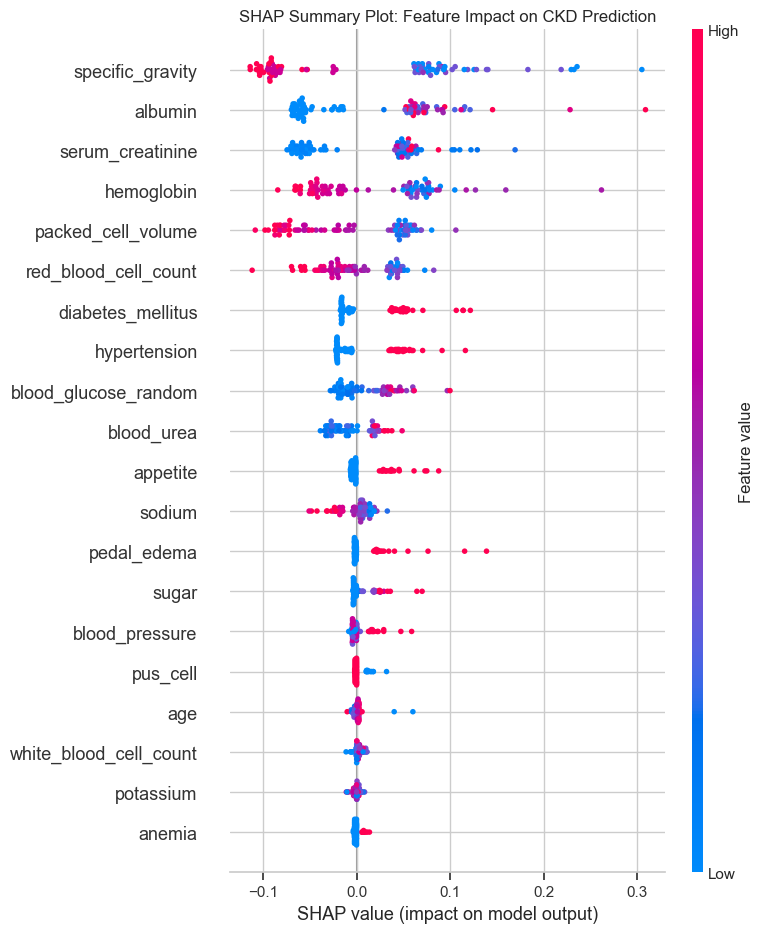

In [58]:
# 3. Global Explainability: SHAP Summary Plot
# This shows how features impact the model across ALL patients
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_ckd, X_test_scaled, show=False)
plt.title("SHAP Summary Plot: Feature Impact on CKD Prediction")
plt.tight_layout()
plt.show()


Explaining prediction for Patient at index 0...
Actual Diagnosis: Not CKD


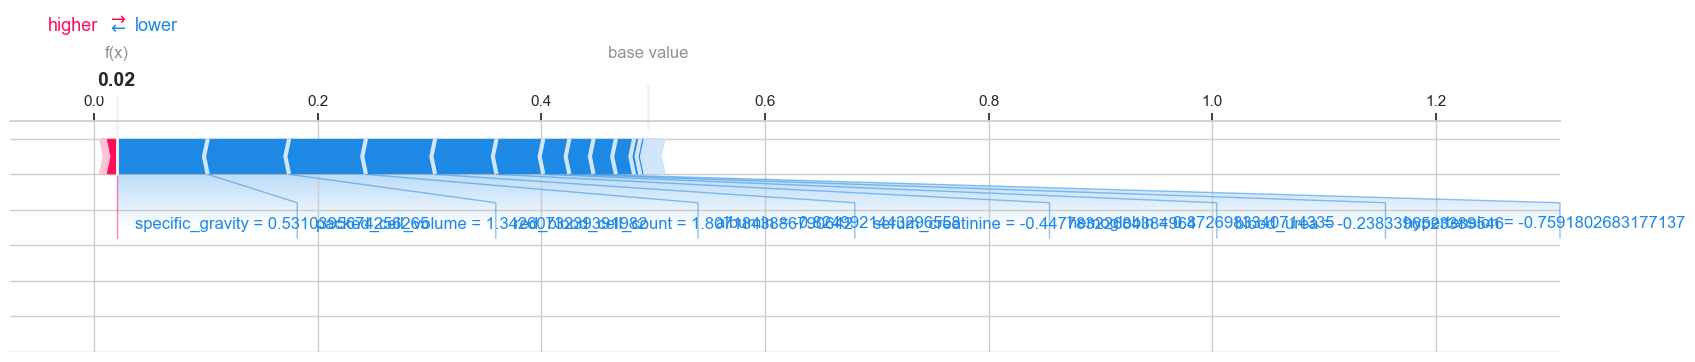

In [59]:
# 4. Local Explainability: Explaining a SINGLE Patient's Diagnosis
# Let's look at the very first patient in our test set
patient_index = 0

# Initialize JavaScript for interactive plots in Jupyter
shap.initjs()

# Generate a Force Plot for Patient 0
print(f"\nExplaining prediction for Patient at index {patient_index}...")
print(f"Actual Diagnosis: {'CKD' if y_test.iloc[patient_index] == 1 else 'Not CKD'}")

# The force plot shows features pushing the prediction higher (red) or lower (blue)
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value, 
    shap_values_ckd[patient_index, :], 
    X_test_scaled.iloc[patient_index, :],
    matplotlib=True # Renders as a static image instead of interactive JS (safer for notebooks)
)

# Model Saving & Deployment Strategy

In [60]:
import joblib
import os

print("Exporting Model and Preprocessing Artifacts...")

# 1. Create a directory to store the files cleanly
os.makedirs('saved_models', exist_ok=True)

# 2. Save the Best Tuned Model
joblib.dump(best_rf_model, 'saved_models/ckd_random_forest_model.pkl')

# 3. Save the Scaler
joblib.dump(scaler, 'saved_models/ckd_scaler.pkl')

# 4. Save the KNN Imputer
joblib.dump(knn_imputer, 'saved_models/ckd_knn_imputer.pkl')

# 5. Save the Label Encoders (Since it's a dictionary, we save the whole dictionary)
joblib.dump(label_encoders, 'saved_models/ckd_label_encoders.pkl')

# 6. Save the exactly expected feature column names
# This is crucial for deployment so we know exactly what order the web app should send data
expected_features = X.columns.tolist()
joblib.dump(expected_features, 'saved_models/ckd_expected_features.pkl')

print("\nSuccess! All artifacts have been saved to the 'saved_models' folder.")
print("You are now ready to build the web application.")

Exporting Model and Preprocessing Artifacts...

Success! All artifacts have been saved to the 'saved_models' folder.
You are now ready to build the web application.
